In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


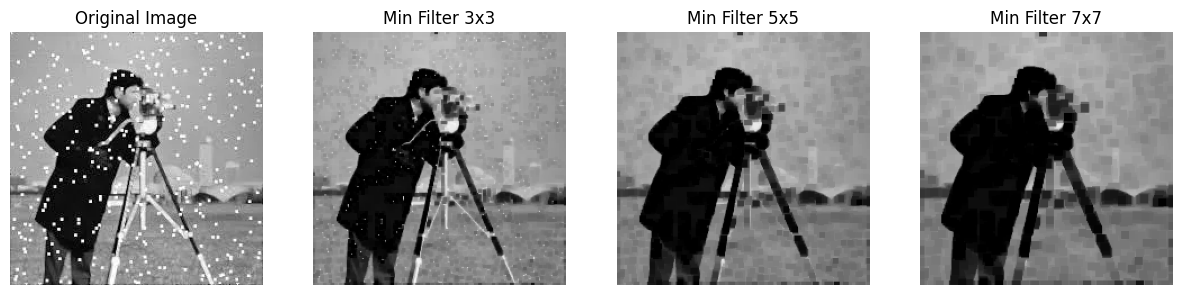

In [2]:

img =cv2.imread('prg-1-saltnoise.jpg',cv2.IMREAD_GRAYSCALE)
kernel_sizes = [3, 5, 7]
fig, axes = plt.subplots(1, len(kernel_sizes) + 1, figsize=(15, 5))


axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis("off")


for i, size in enumerate(kernel_sizes):
    kernel = np.ones((size, size), np.uint8)
    min_filtered = cv2.erode(img, kernel)

    axes[i + 1].imshow(min_filtered, cmap='gray', vmin=0, vmax=255)
    axes[i + 1].set_title(f'Min Filter {size}x{size}')
    axes[i + 1].axis("off")


plt.show()

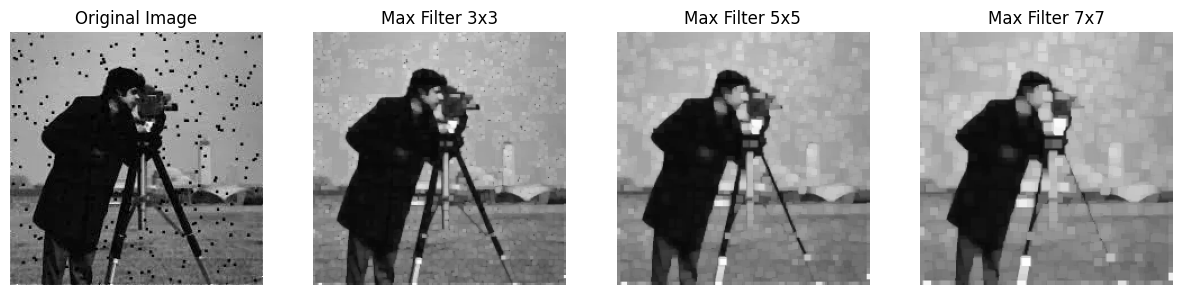

In [3]:

img =cv2.imread('prg-1-peppernoise.jpg',cv2.IMREAD_GRAYSCALE)
kernel_sizes = [3, 5, 7]
fig, axes = plt.subplots(1, len(kernel_sizes) + 1, figsize=(15, 5))


axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis("off")


for i, size in enumerate(kernel_sizes):
    kernel = np.ones((size, size), np.uint8)
    max_filtered = cv2.dilate(img, kernel)

    axes[i + 1].imshow(max_filtered, cmap='gray', vmin=0, vmax=255)
    axes[i + 1].set_title(f'Max Filter {size}x{size}')
    axes[i + 1].axis("off")


plt.show()

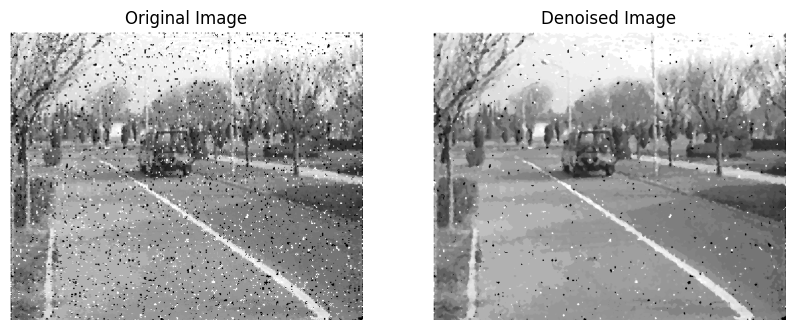

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 215, ..., 255, 255, 221],
       [255,  77,   4, ..., 255, 192, 102],
       ...,
       [255, 128, 128, ...,   4,   4,   4],
       [255, 102, 102, ...,   4,   4,  12],
       [255, 102, 102, ...,   4,   4,  12]], dtype=uint8)

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def remove_salt_and_pepper_noise(image_path, kernel_size=3):

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    
    denoised_img = cv2.medianBlur(img, kernel_size)
    
    
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(img, cmap='gray')
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.title("Denoised Image")
    plt.imshow(denoised_img, cmap='gray')
    plt.axis("off")
    
    plt.show()
    
    return denoised_img
remove_salt_and_pepper_noise('prg-1-imagewithsalt and pepper noise.png')


In [ ]:
image = 'prg-1-imagewithsalt and pepper noise.png'
def midpoint_filter(image, kernel_size):
    image = cv2.imread('prg-1-imagewithsalt and pepper noise.png',cv2.IMREAD_GRAYSCALE)
    min_img = cv2.erode(image, np.ones((kernel_size, kernel_size)))
    max_img = cv2.dilate(image, np.ones((kernel_size, kernel_size)))
    midpoint = cv2.addWeighted(min_img, 0.5, max_img, 0.5, 0)
    return midpoint

for size in kernel_sizes:
    midpoint = midpoint_filter(img, size)
    plt.imshow(midpoint,cmap='gray',vmin=0,vmax=255)



C:\Users\hp\AppData\Local\Temp\ipykernel_18212\3557589921.py:23: RuntimeWarning: overflow encountered in scalar add
  midpoint_value = (min_val + max_val) // 2


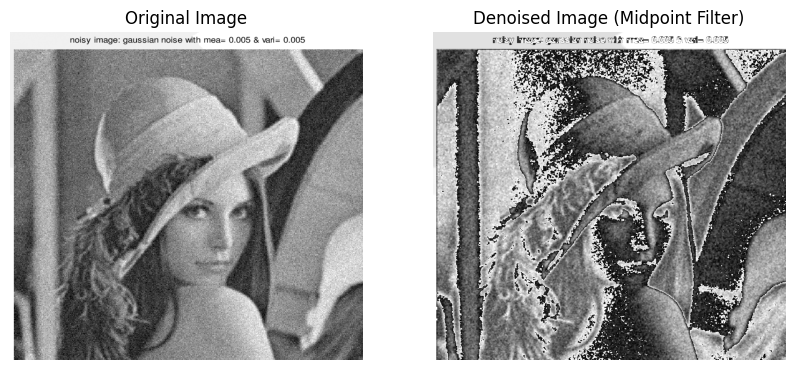

array([[112, 112, 112, ..., 127, 127, 127],
       [112, 112, 112, ..., 127, 127, 127],
       [112, 112, 112, ..., 127, 127, 127],
       ...,
       [127, 127, 127, ...,  91,  92,  92],
       [127, 127, 127, ...,  97, 101, 101],
       [127, 127, 127, ...,  97, 101, 101]], dtype=uint8)

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def midpoint_filter(image_path, kernel_size=3):
    
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
     
    pad_size = kernel_size // 2
    padded_img = cv2.copyMakeBorder(img, pad_size, pad_size, pad_size, pad_size, cv2.BORDER_REPLICATE)
    
    
    denoised_img = np.zeros_like(img)
    
    
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            
            local_region = padded_img[i:i+kernel_size, j:j+kernel_size]
            
            min_val = np.min(local_region)
            max_val = np.max(local_region)
            midpoint_value = (min_val + max_val) // 2
            denoised_img[i, j] = midpoint_value
    
    
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(img, cmap='gray')
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.title("Denoised Image (Midpoint Filter)")
    plt.imshow(denoised_img, cmap='gray')
    plt.axis("off")
    
    plt.show()
    
    return denoised_img

midpoint_filter('prg-1-imagewithgaussiannoise.png')

